# Classer avec la méthode des k-Plus Proches Voisins

Dans ce TP nous allons implémenter notre première Intelligence Artificielle à partir de la méthode des k-Plus Proches Voisins étudiée en TD. Nous allons implémenter, tester, évaluer et étudier cette méthode de classification sur un jeu de données réelles.

## A. Charger, explorer puis préparer le tableau de données

Commencez par importer dans un Dataframe `zoo` les données du fichier `zoo.csv`.

In [40]:
import pandas as pd
import numpy as np

zoo = pd.read_csv('donnees/zoo.csv')

Explorez le dataset `zoo`: Combien d'individus? Combien de descripteurs? Quelle est la nature (type) des descripteurs? Y-a-t'il des valeurs manquantes?

In [41]:
# Explorer le dataset
print(f"Nombre d'individus: {len(zoo)}")
print(f"Nombre de descripteurs: {len(zoo.columns)}")
print(f"\nTypes des descripteurs:")
print(zoo.dtypes)
print(f"\nValeurs manquantes:")
print(zoo.isnull().sum().sum())
print(f"\nAperçu des données:")
zoo.head()

Nombre d'individus: 100
Nombre de descripteurs: 18

Types des descripteurs:
Name         object
hair          int64
feathers      int64
eggs          int64
milk          int64
airbone       int64
aquatic       int64
predator      int64
toothed       int64
backbone      int64
breathes      int64
venomous      int64
fins          int64
legs          int64
tail          int64
domestic      int64
size        float64
type          int64
dtype: object

Valeurs manquantes:
0

Aperçu des données:


,Name,hair,feathers,eggs,milk,airbone,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,size,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,115.0,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,75.0,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,40.0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,210.0,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,120.0,1


Dans ce dataset, la dernière colonne `type` correspond à la catégorie de l'animal :
|  Type  |    Catégorie    |
| :---------:|---------|
| 1 |Mammifères|
| 2 |Oiseaux|
| 3 |Reptiles|
| 4 |Poissons|
| 5 |Amphibiens|
| 6 |Insectes|
| 7 |Invertébrés|

Notre IA devra prédire la catégorie d'un animal à partir de sa description (sans le `Name`). Il s'agit donc d'une tâche de prédiction à **7 classes**.

Observez la distribution des individus selon la variable de classe (`type`) et constatez le déséquilibre des classes. Cela aura-t'il une incidence sur la méthode de k-PPV?

<AxesSubplot: xlabel='type'>

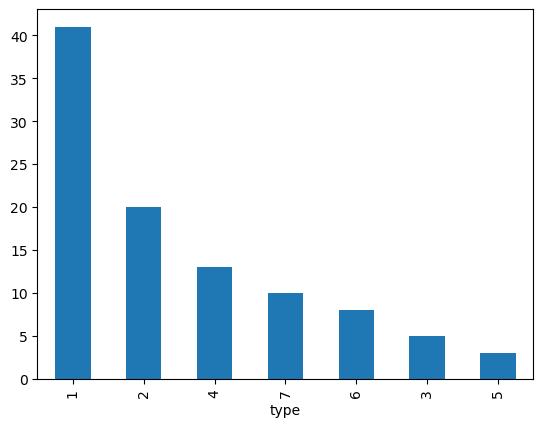

In [42]:
import matplotlib.pyplot as plt
zoo.value_counts('type').plot(kind='bar')
# plt.pie(sizes, labels=labels)
# plt.show()

A partir du dataframe `zoo`, vous allez construire deux tableaux Numpy :
- `X` est la matrice (100x16) des descriptions des individus
- `y` est le vecteur contenant les (100) catégories d'animaux 

In [17]:
# X : matrice des descriptions (sans Name et type)
X = zoo.drop(columns=['Name', 'type'])

# y : vecteur des catégories
y = zoo['type']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (100, 16)
y shape: (100,)


Nous allons à présent découper `X` et `y` en deux sous-ensembles :
- `X_train` : qui contient des individus que la méthode k-PPV utilisera pour prédire
- `X_test`  : qui contient des individus que nous utiliserons pour évaluer notre IA (et ainsi ajuster le paramètre k)
- `y_train` : qui contient les labels des individus de `X_train`
- `y_test`  : qui contient les labels des individus de `X_test`

Ecrire une fonction (générique) `train_test_split(X, y, train_ratio)` qui réalise un tel découpage :

In [28]:
def train_test_split(X, y, train_ratio):
    """découpe un dataset X en deux ensembles d'entraînement (train) et de test ainsi que les labels associés

    Args:
        X (matrice Numpy): le dataset à découper
        y (vecteur Numpy): le vecteur des labels à découper
        train_ratio (float): entre 0.0 et 1.0 = proportion du dataset à inclure dans l'ensemble d'entraînement (train)

    Returns:
        X_train (matrice Numpy): le sous-ensemble d'entraînement
        X_test (matrice Numpy):  le sous-ensemble de test
        y_train (vecteur Numpy): les labels données d'entraînement
        y_test (vecteur Numpy):  les labels données de test

    """
    # Mélanger aléatoirement les indices
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    # Calculer le nombre d'échantillons pour l'entraînement
    train_size = int(len(X) * train_ratio)
    
    # Diviser les indices
    train_indices = indices[:train_size]
    test_indices = indices[train_size:]
    
    # Créer les sous-ensembles (convertir en array numpy)
    X_train = X.iloc[train_indices].values if hasattr(X, 'iloc') else X[train_indices]
    X_test = X.iloc[test_indices].values if hasattr(X, 'iloc') else X[test_indices]
    y_train = y.iloc[train_indices].values if hasattr(y, 'iloc') else y[train_indices]
    y_test = y.iloc[test_indices].values if hasattr(y, 'iloc') else y[test_indices]
    
    return X_train, X_test, y_train, y_test

Utilisez votre fonction pour découper notre dataset `X` en deux sous-ensembles de mêmes tailles.

Vérifiez que les déséquilibres des classes sont globalement respectés (relancez le découpage si certaines classes sont absentes dans l'un des deux sous-ensembles).

In [30]:
# Découper en deux sous-ensembles de même taille
X_train, X_test, y_train, y_test = train_test_split(X, y, 0.5)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nDistribution dans y_train:")
print(np.unique(y_train, return_counts=True))
print(f"\nDistribution dans y_test:")
print(np.unique(y_test, return_counts=True))

X_train shape: (50, 16)
X_test shape: (50, 16)

Distribution dans y_train:
(array([1, 2, 3, 4, 5, 6, 7]), array([23,  9,  2,  9,  1,  3,  3]))

Distribution dans y_test:
(array([1, 2, 3, 4, 5, 6, 7]), array([18, 11,  3,  4,  2,  5,  7]))


---

## B. Implémenter et évaluer la méthode k-PPV (non-pondérée)

Définissez une fonction `predict_kNN(k, X, y, x_new)` qui prédit la classe d'une description `x_new` par la méthodes k-PPV non-pondérée utilisée sur les données `X` de ayant pour labels `y` avec la distance Euclidienne.

In [35]:
def predict_kNN(k, X, y, x_new):
    """implémente le classifieur du k-Plus Proches Voisins 

    Args:
        k (int): nombre de voisins à utiliser pour prédire
        X (matrice Numpy): le dataset des données d'entraînement
        y (vecteur Numpy): le vecteur des labels des données d'entraînement
        x_new (vecteur Numpy) : le vecteur de description d'une nouvelle donnée à classer

    Returns:
        y_new (label):  le label prédit

    """
    # Calculer les distances euclidiennes entre x_new et tous les points de X
    distances = np.sqrt(np.sum((X - x_new)**2, axis=1))
    
    # Trouver les indices des k plus proches voisins
    k_nearest_indices = np.argsort(distances)[:k]
    
    # Récupérer les labels des k plus proches voisins
    k_nearest_labels = y[k_nearest_indices]
    
    # Prédire la classe la plus fréquente parmi les k voisins
    unique_labels, counts = np.unique(k_nearest_labels, return_counts=True)
    y_new = unique_labels[np.argmax(counts)]
    
    return y_new

Utilisez la fonction `predict_kNN` pour prédire la classe de l'individu situé à l'indice 23 dans `X_test` à partir des données d'entraînement (`X_train`, `y_train`). Affichez la classe prédite selon différentes valeurs de `k` et comparez avec la vraie classe de l'individu (`y_test[23]`). 

In [31]:
# Prédire la classe de l'individu 23 avec différentes valeurs de k
print(f"Vraie classe: {y_test[23]}")
print()
for k in [1, 3, 5, 7, 9]:
    y_pred = predict_kNN(k, X_train, y_train, X_test[23])
    print(f"k={k}: classe prédite = {y_pred}")

Vraie classe: 7

k=1: classe prédite = 4
k=3: classe prédite = 2
k=5: classe prédite = 1
k=7: classe prédite = 1
k=9: classe prédite = 1


Définissez une fonction `error_kNN(k, X_train, y_train, X_test, y_test)` qui renvoie le taux d'erreur de prédiction de la méthode k-PPV sur des données de test. 

In [27]:
def error_kNN(k, X_train, y_train, X_test, y_test,):
    """calcule le taux d'erreur de prédiction par k-PPV sur les données de test 

    Args:
        k (int): nombre de voisins à utiliser pour prédire
        X_train (matrice Numpy): le dataset des données d'entraînement
        y_train (vecteur Numpy): le vecteur des labels des données d'entraînement
        X_test (vecteur Numpy) : le dataset des données de test
        y_test (vecteur Numpy): le vecteur des labels des données de test


    Returns:
        error_rate (float):  le taux d'erreur de prédiciton (Nb. mauvaises prédictions / Nb. prédictions)

    """
    # Prédire pour chaque individu de test
    errors = 0
    for i in range(len(X_test)):
        y_pred = predict_kNN(k, X_train, y_train, X_test[i])
        if y_pred != y_test[i]:
            errors += 1
    
    # Calculer le taux d'erreur
    error_rate = errors / len(X_test)
    return error_rate

Tracez la courbe du taux d'erreur en fonction du paramètre `k`. Quelle valeur choisirez-vous pour `k`? Est-ce que votre classifieur vous semble performant?

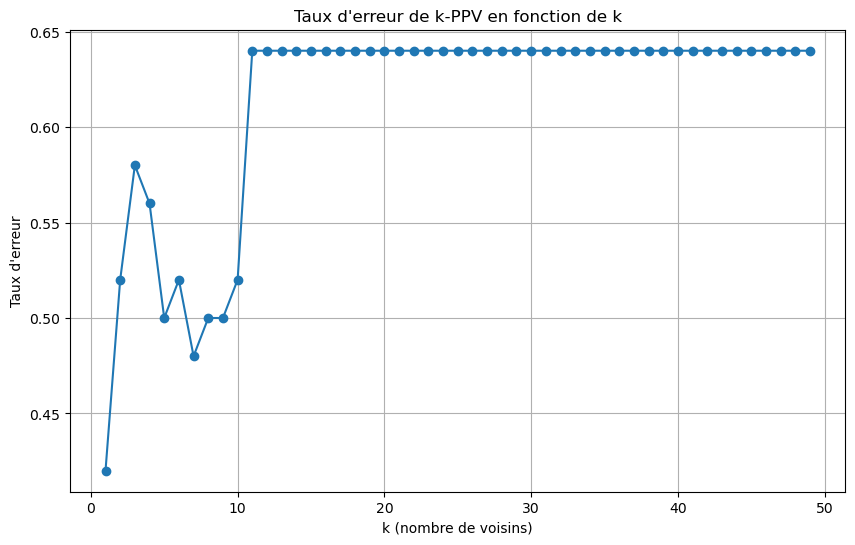


Meilleure valeur de k: 1
Taux d'erreur minimal: 42.00%


In [43]:
# Tracer la courbe du taux d'erreur en fonction de k
k_values = range(1, 50)
error_rates = [error_kNN(k, X_train, y_train, X_test, y_test) for k in k_values]

plt.figure(figsize=(10, 6))
plt.plot(k_values, error_rates, marker='o')
plt.xlabel('k (nombre de voisins)')
plt.ylabel('Taux d\'erreur')
plt.title('Taux d\'erreur de k-PPV en fonction de k')
plt.grid(True)
plt.show()

# Trouver la meilleure valeur de k
best_k = k_values[np.argmin(error_rates)]
best_error = min(error_rates)
print(f"\nMeilleure valeur de k: {best_k}")
print(f"Taux d'erreur minimal: {best_error:.2%}")

Avant de conclure (trop vite!)... quel serait le taux d'erreur d'un classifieur k-PPV qui fonderait ses prédictions sur la taille des animaux uniquement (descripteur `size`)?

In [33]:
# Tester avec uniquement le descripteur 'size'
# La colonne 'size' est à l'index 11 dans X (après avoir enlevé Name)
# Vérifier en regardant les colonnes de zoo
print("Colonnes du dataset (sans Name et type):")
print(zoo.drop(columns=['Name', 'type']).columns.tolist())

# On suppose que 'size' est à l'index correspondant
size_index = zoo.drop(columns=['Name', 'type']).columns.tolist().index('size')
print(f"\nIndex de 'size': {size_index}")

# Créer X avec seulement la colonne size
X_train_size = X_train[:, size_index].reshape(-1, 1)
X_test_size = X_test[:, size_index].reshape(-1, 1)

# Calculer l'erreur avec k=3
error_size = error_kNN(3, X_train_size, y_train, X_test_size, y_test)
print(f"\nTaux d'erreur avec seulement 'size' (k=3): {error_size:.2%}")
print(f"Taux d'erreur avec tous les descripteurs (k=3): {error_kNN(3, X_train, y_train, X_test, y_test):.2%}")

Colonnes du dataset (sans Name et type):
['hair', 'feathers', 'eggs', 'milk', 'airbone', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'size']

Index de 'size': 15

Taux d'erreur avec seulement 'size' (k=3): 60.00%
Taux d'erreur avec tous les descripteurs (k=3): 58.00%


## C. Normaliser les données

Vous avez constaté que tous les descriteurs n'ont pas la même influence dans le calcul des distances entre individus, du fait de l'amplitude des valeurs associée à chaque descripteurs.

Pour faire en sorte que chaque descripteur ait la même influence dans le traitement du tableau de données, on procède à une **normalisation** des données. 

> Normaliser un ensemble $Z$ consiste à ramener toutes ses valeurs dans l'intervalle $[0,1]$ par l'opération : $$\tilde{z}_{i}=\frac{z_{i}-min_Z}{max_Z-min_Z}$$
>

Complétez la classe `Normalizer` ci-dessous qui définit un **outil** de normalisation d'un jeu de données. La normalisation d'un jeu de données procédera en deux temps :
- calcul des paramètres de la fonction de normalisation sur des données (méthode `.fit()`)
- application de la fonction de normalisation sur des données (méthode `.transform()`)

In [1]:
class Normalizer:
    
    def __init__(self):
        self.min_vals = None
        self.max_vals = None
    
    def fit(self, X):
        """calcule les min et max de chaque colonne de X et les stocke"""
        self.min_vals = X.min()
        self.max_vals = X.max()
        return self
    
    def transform(self, X):
        """renvoie X normalisé en utilisant les min et max calculés"""
        if self.min_vals is None or self.max_vals is None:
            raise ValueError("Vous devez d'abord appeler fit() avant transform()")
        
        X_normalized = (X - self.min_vals) / (self.max_vals - self.min_vals)
        return X_normalized
    
    def fit_transform(self, X):
        """calcule les min/max et renvoie X normalisé en une seule opération"""
        self.fit(X)
        return self.transform(X)

normaliser = Normalizer()

Appliquez la normalisation sur l'ensemble des individus (100 descriptions) puis comparez l'erreur faite par la méthode des k-PPV avant et après normalisation. Concluez sur l'utilité de cette étape de normalisation.

Comparaison avant et après normalisation:
k	Sans normalisation	Avec normalisation
--------------------------------------------------
1	42.00%			0.00%
3	58.00%			6.00%
5	50.00%			6.00%
7	48.00%			8.00%
9	50.00%			14.00%


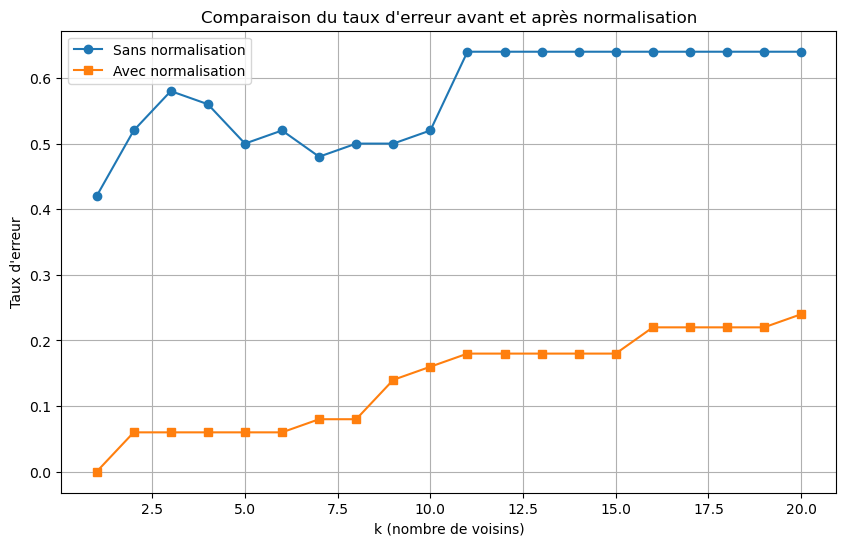


✓ La normalisation améliore significativement les résultats!
  Meilleur k sans normalisation: 1 (erreur: 42.00%)
  Meilleur k avec normalisation: 1 (erreur: 0.00%)


In [36]:
# Appliquer la normalisation sur X, X_train et X_test
X_normalized = normaliser.fit_transform(X)

# Redécouper les données normalisées
X_train_norm, X_test_norm, y_train_norm, y_test_norm = train_test_split(X_normalized, y, 0.5)

# Calculer les erreurs avant et après normalisation avec différentes valeurs de k
print("Comparaison avant et après normalisation:")
print("k\tSans normalisation\tAvec normalisation")
print("-" * 50)
for k in [1, 3, 5, 7, 9]:
    error_without = error_kNN(k, X_train, y_train, X_test, y_test)
    error_with = error_kNN(k, X_train_norm, y_train_norm, X_test_norm, y_test_norm)
    print(f"{k}\t{error_without:.2%}\t\t\t{error_with:.2%}")

# Tracer les courbes comparatives
k_values = range(1, 21)
error_rates_without = [error_kNN(k, X_train, y_train, X_test, y_test) for k in k_values]
error_rates_with = [error_kNN(k, X_train_norm, y_train_norm, X_test_norm, y_test_norm) for k in k_values]

plt.figure(figsize=(10, 6))
plt.plot(k_values, error_rates_without, marker='o', label='Sans normalisation')
plt.plot(k_values, error_rates_with, marker='s', label='Avec normalisation')
plt.xlabel('k (nombre de voisins)')
plt.ylabel('Taux d\'erreur')
plt.title('Comparaison du taux d\'erreur avant et après normalisation')
plt.legend()
plt.grid(True)
plt.show()

print(f"\n✓ La normalisation améliore significativement les résultats!")
print(f"  Meilleur k sans normalisation: {k_values[np.argmin(error_rates_without)]} (erreur: {min(error_rates_without):.2%})")
print(f"  Meilleur k avec normalisation: {k_values[np.argmin(error_rates_with)]} (erreur: {min(error_rates_with):.2%})")

## D. Implémenter et évaluer la méthode k-PPV pondérée

Implémentez la variante pondérée de la méthode k-PPV dans une version généralisée de la fonction `predict_kNN(k, X, y, x_new, weights)`

In [37]:
def predict_kNN(k, X, y, x_new, weights='uniform'):
    """implémente le classifieur du k-Plus Proches Voisins 

    Args:
        k (int): nombre de voisins à utiliser pour prédire
        X (matrice Numpy): le dataset des données d'entraînement
        y (vecteur Numpy): le vecteur des labels des données d'entraînement
        x_new (vecteur Numpy) : le vecteur de description d'une nouvelle donnée à classer
        weights ('uniform', 'distance') : méthode de pondération utilisée pour la prédiction

    Returns:
        y_new (label):  le label prédit

    """
    # Calculer les distances euclidiennes entre x_new et tous les points de X
    distances = np.sqrt(np.sum((X - x_new)**2, axis=1))
    
    # Trouver les indices des k plus proches voisins
    k_nearest_indices = np.argsort(distances)[:k]
    
    # Récupérer les labels et distances des k plus proches voisins
    k_nearest_labels = y[k_nearest_indices]
    k_nearest_distances = distances[k_nearest_indices]
    
    if weights == 'uniform':
        # Cas non-pondéré: chaque voisin a le même poids
        unique_labels, counts = np.unique(k_nearest_labels, return_counts=True)
        y_new = unique_labels[np.argmax(counts)]
    
    elif weights == 'distance':
        # Cas pondéré par l'inverse de la distance
        # Éviter les divisions par zéro pour les distances = 0
        weights_vals = np.zeros(k)
        for i in range(k):
            if k_nearest_distances[i] == 0:
                weights_vals[i] = 1.0  # Mettre un poids élevé si distance = 0
            else:
                weights_vals[i] = 1.0 / k_nearest_distances[i]
        
        # Calculer le score pour chaque classe
        unique_labels = np.unique(k_nearest_labels)
        scores = {}
        for label in unique_labels:
            mask = k_nearest_labels == label
            scores[label] = np.sum(weights_vals[mask])
        
        # Prédire la classe avec le score le plus élevé
        y_new = max(scores, key=scores.get)
    
    else:
        raise ValueError("weights doit être 'uniform' ou 'distance'")
    
    return y_new

Généralisez également la fonction d'évaluation `error_kNN(k, X_train, y_train, X_test, y_test, weights)` avec l'argument supplémentaire `weights`

In [38]:
def error_kNN(k, X_train, y_train, X_test, y_test, weights='uniform'):
    """calcule le taux d'erreur de prédiction par k-PPV sur les données de test 

    Args:
        k (int): nombre de voisins à utiliser pour prédire
        X_train (matrice Numpy): le dataset des données d'entraînement
        y_train (vecteur Numpy): le vecteur des labels des données d'entraînement
        X_test (vecteur Numpy) : le dataset des données de test
        y_test (vecteur Numpy): le vecteur des labels des données de test
        weights ('uniform', 'distance') : méthode de pondération utilisée dans k-PPV


    Returns:
        error_rate (float):  le taux d'erreur de prédiciton (Nb. mauvaises prédictions / Nb. prédictions)

    """
    # Prédire pour chaque individu de test
    errors = 0
    for i in range(len(X_test)):
        y_pred = predict_kNN(k, X_train, y_train, X_test[i], weights=weights)
        if y_pred != y_test[i]:
            errors += 1
    
    # Calculer le taux d'erreur
    error_rate = errors / len(X_test)
    return error_rate

Enfin, comparez l'erreur faite par chacune des deux versions de la méthode k-PPV (pondérée ou non).

Comparaison des deux versions de k-PPV:
k	k-PPV non-pondéré	k-PPV pondéré (distance)
----------------------------------------------------------------------
1	0.00%			0.00%
2	6.00%			0.00%
3	6.00%			4.00%
4	6.00%			6.00%
5	6.00%			6.00%
6	6.00%			6.00%
7	8.00%			8.00%
8	8.00%			8.00%
9	14.00%			10.00%
10	16.00%			14.00%
15	18.00%			16.00%
20	24.00%			18.00%


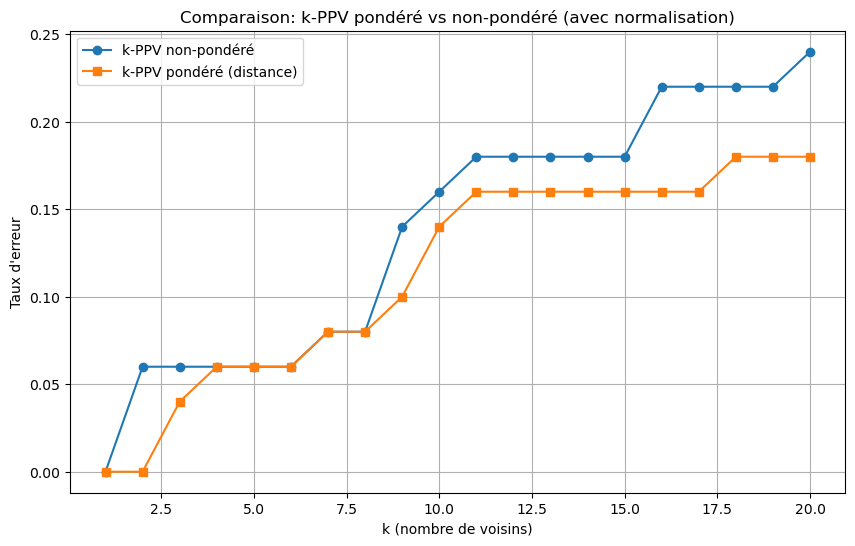


RÉSULTATS FINAUX:
----------------------------------------------------------------------
k-PPV non-pondéré:  meilleur k = 1, taux d'erreur = 0.00%
k-PPV pondéré:      meilleur k = 1, taux d'erreur = 0.00%
≈ Les deux méthodes donnent les mêmes résultats


In [39]:
# Comparer les deux versions de k-PPV (pondérée et non-pondérée)
print("Comparaison des deux versions de k-PPV:")
print("=" * 70)
print("k\tk-PPV non-pondéré\tk-PPV pondéré (distance)")
print("-" * 70)

k_values = range(1, 21)
error_uniform = []
error_distance = []

for k in k_values:
    err_uniform = error_kNN(k, X_train_norm, y_train_norm, X_test_norm, y_test_norm, weights='uniform')
    err_distance = error_kNN(k, X_train_norm, y_train_norm, X_test_norm, y_test_norm, weights='distance')
    error_uniform.append(err_uniform)
    error_distance.append(err_distance)
    if k <= 10 or k % 5 == 0:
        print(f"{k}\t{err_uniform:.2%}\t\t\t{err_distance:.2%}")

# Tracer les courbes comparatives
plt.figure(figsize=(10, 6))
plt.plot(k_values, error_uniform, marker='o', label='k-PPV non-pondéré')
plt.plot(k_values, error_distance, marker='s', label='k-PPV pondéré (distance)')
plt.xlabel('k (nombre de voisins)')
plt.ylabel('Taux d\'erreur')
plt.title('Comparaison: k-PPV pondéré vs non-pondéré (avec normalisation)')
plt.legend()
plt.grid(True)
plt.show()

# Résumé des meilleurs résultats
best_k_uniform = k_values[np.argmin(error_uniform)]
best_error_uniform = min(error_uniform)
best_k_distance = k_values[np.argmin(error_distance)]
best_error_distance = min(error_distance)

print("\n" + "=" * 70)
print("RÉSULTATS FINAUX:")
print("-" * 70)
print(f"k-PPV non-pondéré:  meilleur k = {best_k_uniform}, taux d'erreur = {best_error_uniform:.2%}")
print(f"k-PPV pondéré:      meilleur k = {best_k_distance}, taux d'erreur = {best_error_distance:.2%}")
print("=" * 70)

if best_error_distance < best_error_uniform:
    print(f"✓ La pondération par distance améliore les résultats!")
elif best_error_distance > best_error_uniform:
    print(f"✗ La pondération par distance détériore les résultats")
else:
    print(f"≈ Les deux méthodes donnent les mêmes résultats")